In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

from catboost import CatBoostClassifier

In [2]:
train = pd.read_csv("../data/train.csv")

print(train.shape)
train.head()

(690088, 15)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [5]:
import os ,sys
sys.path.append(os.path.abspath(".."))
from src.preprocessing import preprocess
from src.feature_engineering import create_features

train_processed = preprocess(train.copy())
train_processed = create_features(train_processed)

In [6]:
X = train_processed.drop(columns=["health_condition"])
y = train_processed["health_condition"]

print(X.shape)

(690088, 33)


In [9]:
import json

with open("../output/models/best_params.json", "r") as f:
    best_params = json.load(f)

best_params

{'bootstrap_type': 'Bernoulli',
 'learning_rate': 0.03309416821002669,
 'depth': 7,
 'l2_leaf_reg': 10.801507310686478,
 'random_strength': 0.898531201248234,
 'border_count': 253,
 'grow_policy': 'Depthwise',
 'leaf_estimation_iterations': 9,
 'min_data_in_leaf': 25,
 'subsample': 0.6828948177465322,
 'iterations': 1200,
 'loss_function': 'MultiClass',
 'eval_metric': 'MultiClass',
 'task_type': 'GPU',
 'devices': '0',
 'random_seed': 42,
 'verbose': 200,
 'auto_class_weights': 'Balanced'}

In [14]:
print(X.dtypes)

sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                      str
stress_level                   str
sleep_quality                  str
physical_activity_level        str
smoking_alcohol                str
gender                         str
activity_score             float64
calories_per_step          float64
water_per_exercise         float64
exercise_sleep_ratio       float64
steps_per_minute           float64
calories_per_minute        float64
activity_density           float64
heart_activity             float64
heart_steps                float64
bmi_sleep                  float64
bmi_water                  float64
hydration_score            float64
health_index               float64
bmi_category                   str
bmi_risk                       str
stress_sleep        

In [15]:
X.select_dtypes(include="object").columns

Index(['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender', 'bmi_category', 'bmi_risk', 'stress_sleep',
       'activity_diet', 'gender_activity', 'smoking_stress', 'diet_smoking'],
      dtype='str')

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from catboost import CatBoostClassifier
import numpy as np

# Categorical feature names
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_predictions = np.empty(len(y), dtype=object)
fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

    print("=" * 60)
    print(f"Fold {fold}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostClassifier(**best_params)

    model.fit(
        X_train,
        y_train,
        cat_features=categorical_features,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
        early_stopping_rounds=150,
        verbose=False
    )

    preds = model.predict(X_valid).ravel()

    oof_predictions[valid_idx] = preds

    score = balanced_accuracy_score(y_valid, preds)
    fold_scores.append(score)

    print(f"Balanced Accuracy: {score:.5f}")

print("=" * 60)
print(f"Mean CV Score : {np.mean(fold_scores):.5f}")
print(f"Std CV Score  : {np.std(fold_scores):.5f}")

Categorical Features:
['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'bmi_category', 'bmi_risk', 'stress_sleep', 'activity_diet', 'gender_activity', 'smoking_stress', 'diet_smoking']
Fold 1
Balanced Accuracy: 0.94997
Fold 2
Balanced Accuracy: 0.95140
Fold 3
Balanced Accuracy: 0.94896
Fold 4
Balanced Accuracy: 0.94913
Fold 5
Balanced Accuracy: 0.94770
Mean CV Score : 0.94943
Std CV Score  : 0.00122


In [18]:
overall_score = balanced_accuracy_score(y, oof_predictions)

print(f"Overall OOF Balanced Accuracy: {overall_score:.5f}")

Overall OOF Balanced Accuracy: 0.94943


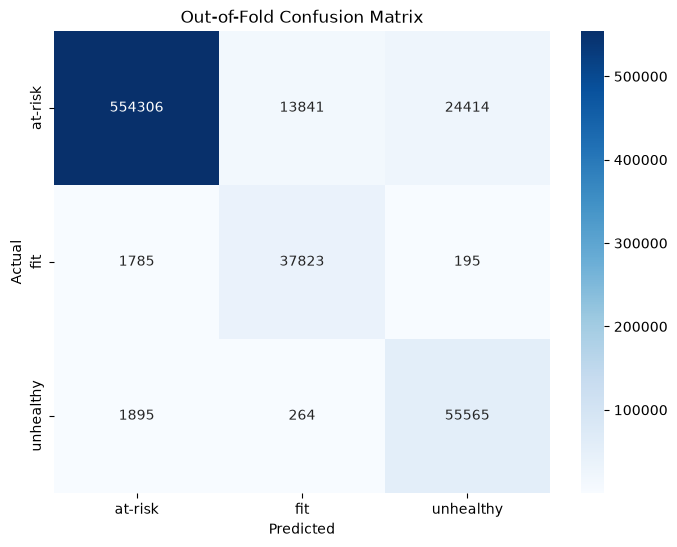

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y, oof_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Out-of-Fold Confusion Matrix")

plt.show()

In [20]:
errors = train.copy()

errors["Actual"] = y.values
errors["Predicted"] = oof_predictions

misclassified = errors[
    errors["Actual"] != errors["Predicted"]
]

print(f"Misclassified Samples: {len(misclassified):,}")

misclassified.head()

Misclassified Samples: 42,394


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,Actual,Predicted
10,10,at-risk,NaN,77.5,21.91,2484.0,12107.0,50.0,2.51,balanced,high,average,active,no,female,at-risk,unhealthy
11,11,at-risk,8.64,83.8,24.58,1875.0,8335.0,NaN,1.57,balanced,NaN,poor,active,no,other,at-risk,fit
34,34,at-risk,4.77,74.1,22.49,1848.0,7484.0,37.0,2.33,balanced,NaN,average,sedentary,no,male,at-risk,unhealthy
37,37,at-risk,8.00,74.3,22.48,2197.0,9359.0,50.6,2.49,veg,NaN,average,active,occasional,male,at-risk,fit
43,43,at-risk,NaN,73.6,23.20,1557.0,5784.0,35.4,1.54,non-veg,NaN,poor,sedentary,occasional,male,at-risk,unhealthy
